<div style="background:#1F3864;padding:20px 26px;border-radius:10px;margin-bottom:14px"><h2 style="color:#A8C8E8;margin:0 0 4px">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:0 0 6px">NB14 (Bonus) — Live Apple Watch XAI Stream — Real Sensor Data via iPhone Shortcut</h3><p style="color:#D0E4F4;margin:0">Module 4 Bonus: Real-Time IoMT Demo | Prof. Dr. Utku Kose | Universidad Panamericana &amp; SDU</p><p style="color:#A8D8B0;margin:4px 0 0;font-size:0.9em">&#x1F4CA; Your real Apple Watch sensor data (HR, HRV, SpO2, steps, resp rate) via HealthKit</p><p style="color:#D4C4F0;margin:4px 0 0;font-size:0.88em">&#x1F4CB; S1: Architecture &amp; setup &#xb7; S2: Flask receiver server &#xb7; S3: iPhone Shortcut guide &#xb7; S4: Live inference engine &#xb7; S5: Live XAI dashboard &#xb7; S6: Offline fallback demo</p></div>

## What This Notebook Does

This bonus notebook connects your real Apple Watch sensor data to the XAI pipeline from NB11 and NB12, giving a **live updating dashboard** without requiring any iOS app development.

### Architecture

```
Apple Watch
    │  (Bluetooth, automatic)
    ▼
iPhone HealthKit
    │  (triggered by you — one tap on a Shortcut)
    ▼
iPhone Shortcut → HTTP POST → Flask server (running in this notebook)
    │  (saves latest readings as JSON)
    ▼
File watcher → GBM inference → TreeSHAP
    │  (runs every time new data arrives)
    ▼
Live animated dashboard (updates in this notebook)
```

### What "live" means here

| Approach | Update rate | Setup required |
|---|---|---|
| **This notebook (Shortcut)** | Every time you tap (manual) or every 1–5 min (automated Shortcut) | 5 minutes on iPhone — no coding |
| True live stream | Every second | iOS companion app in Swift — significant development work |
| NB12 batch mode | Once per export | Export + import each time |

The Shortcut approach gives genuine real sensor readings updating at a rate that is clinically meaningful — AFib risk assessment every 1–5 minutes is appropriate for a monitoring scenario.

### Prerequisites
- Apple Watch Series 1 or later (Series 4+ recommended for HRV + SpO2)
- iPhone with Health app (iOS 14+)
- Jupyter running on the **same Wi-Fi network** as your iPhone
- Python packages: numpy, pandas, matplotlib, sklearn, shap, flask (all standard)

## Setup

In [7]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import json, os, time, threading, socket
from datetime import datetime, timedelta
from collections import deque
from pathlib import Path

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
import shap
from flask import Flask, request, jsonify

# Colour palette
NAVY='#1F3864'; BLUE='#2E75B6'; GREEN='#1F7A5C'; RED='#C0392B'
PURPLE='#7B3F9E'; ORANGE='#D4860B'; TEAL='#117A8B'; GREY='#6C757D'

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})

# ── Data directory ────────────────────────────────────────────────────────────
DATA_DIR  = Path('apple_watch_live')
DATA_DIR.mkdir(exist_ok=True)
DATA_FILE = DATA_DIR / 'latest_readings.json'
LOG_FILE  = DATA_DIR / 'stream_log.jsonl'

print("Setup complete.")
print(f"Live data directory: {DATA_DIR.resolve()}")
print()

# ── Get local IP address for Shortcut configuration ───────────────────────────
def get_local_ip():
    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        s.connect(('8.8.8.8', 80))
        ip = s.getsockname()[0]
        s.close()
        return ip
    except Exception:
        return '127.0.0.1'

LOCAL_IP   = get_local_ip()
FLASK_PORT = 5050

print(f"Your computer's IP address: {LOCAL_IP}")
print(f"Flask server port:          {FLASK_PORT}")
print()
print(f"iPhone Shortcut URL (you will need this in Section 3):")
print(f"  http://{LOCAL_IP}:{FLASK_PORT}/watch")
print()
print("IMPORTANT: Your iPhone and this computer must be on the same Wi-Fi network.")


Setup complete.
Live data directory: C:\Users\Dell\Desktop\__UnivPanamericana_XAI-Course\Module_4\2_Codes\apple_watch_live

Your computer's IP address: 192.168.1.111
Flask server port:          5050

iPhone Shortcut URL (you will need this in Section 3):
  http://192.168.1.111:5050/watch

IMPORTANT: Your iPhone and this computer must be on the same Wi-Fi network.


---
## Section 1 — Train the AFib Risk Model — Same Pipeline as NB11/NB12

> We train the GBM on synthetic data first so the model is ready before any real data arrives. Once real readings accumulate, you can retrain on your own history.


In [8]:
# ── Generate synthetic training data (same generator as NB12) ───────────────
def generate_watch_cohort(n_patients=300, n_hours=168, afib_prev=0.30, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    t = np.arange(n_hours)
    hod = t % 24  # hour of day

    for pid in range(n_patients):
        is_afib   = pid < int(n_patients * afib_prev)
        base_hr   = rng.uniform(58, 80)
        base_hrv  = rng.uniform(30, 65)
        base_spo2 = rng.uniform(96.5, 99.0)
        base_rr   = rng.uniform(13, 18)
        diurnal   = 10 * np.sin(2 * np.pi * (hod - 10) / 24)

        hr   = base_hr + diurnal + rng.normal(0, 3, n_hours)
        hrv  = base_hrv + rng.normal(0, 6, n_hours)
        spo2 = base_spo2 + rng.normal(0, 0.3, n_hours)
        rr   = base_rr + rng.normal(0, 1.0, n_hours)
        steps = np.where(hod < 7, rng.integers(0,50,n_hours),
                         rng.integers(100,600,n_hours)).astype(float)

        if is_afib:
            n_ep = rng.integers(3, 12)
            for _ in range(n_ep):
                s = rng.integers(0, n_hours - 8)
                e = min(s + rng.integers(2, 8), n_hours)
                hr[s:e]  += rng.uniform(20, 50)
                hrv[s:e] += rng.uniform(80, 160)
                spo2[s:e] -= rng.uniform(1, 3)

        charging = (hod == 23) | (hod == 0)
        hr[charging] = np.nan; hrv[charging] = np.nan
        spo2[charging] = np.nan; rr[charging] = np.nan
        hrv[rng.random(n_hours) > 0.65] = np.nan

        for h in range(n_hours):
            rows.append({'patient_id':pid, 'hour':h, 'hour_of_day':int(hod[h]),
                         'heart_rate':float(np.clip(hr[h],35,200)) if not np.isnan(hr[h]) else np.nan,
                         'hrv_sdnn':float(np.clip(hrv[h],5,300)) if not np.isnan(hrv[h]) else np.nan,
                         'spo2':float(np.clip(spo2[h],85,100)) if not np.isnan(spo2[h]) else np.nan,
                         'step_count':float(np.clip(steps[h],0,5000)),
                         'resp_rate':float(np.clip(rr[h],8,35)) if not np.isnan(rr[h]) else np.nan,
                         'is_afib':int(is_afib)})
    return pd.DataFrame(rows)

SENSOR_COLS = ['heart_rate','hrv_sdnn','spo2','step_count','resp_rate']
WINDOW_H    = 6
STEP_H      = 2

def extract_features(df_cohort):
    X_list, y_list, pid_list = [], [], []
    for pid, grp in df_cohort.groupby('patient_id'):
        grp   = grp.sort_values('hour').reset_index(drop=True)
        label = grp.is_afib.iloc[0]
        for start in range(0, len(grp) - WINDOW_H, STEP_H):
            w = grp.iloc[start:start+WINDOW_H]
            if w.heart_rate.notna().mean() < 0.5:
                continue
            row = {}
            for col in SENSOR_COLS:
                v = w[col].dropna().values
                if len(v) == 0: v = np.array([0.0])
                row[f'{col}_mean']  = v.mean()
                row[f'{col}_std']   = v.std() if len(v)>1 else 0.0
                row[f'{col}_min']   = v.min()
                row[f'{col}_max']   = v.max()
                row[f'{col}_last']  = v[-1]
                row[f'{col}_trend'] = float(np.polyfit(range(len(v)),v,1)[0]) if len(v)>1 else 0.0
            row['hr_irregularity'] = row['heart_rate_std'] / max(row['heart_rate_mean'],1)
            row['hrv_hr_ratio']    = row['hrv_sdnn_mean']  / max(row['heart_rate_mean'],1)
            row['spo2_deficit']    = max(0, 94.0 - row['spo2_mean'])
            row['night_hr_low']    = int(w.hour_of_day.mean() < 7)
            X_list.append(row); y_list.append(label); pid_list.append(pid)
    return pd.DataFrame(X_list), np.array(y_list), np.array(pid_list)

print("Generating synthetic training cohort...")
t0 = time.time()
df_syn, _ = generate_watch_cohort(n_patients=300), None
df_cohort = generate_watch_cohort(n_patients=300)
X_all, y_all, pids_all = extract_features(df_cohort)
FEAT_NAMES = X_all.columns.tolist()

# Patient-stratified split
uniq_p = np.unique(pids_all)
tr_p, te_p = train_test_split(uniq_p, test_size=0.2, random_state=42)
tr_m = np.isin(pids_all, tr_p); te_m = np.isin(pids_all, te_p)
X_tr, X_te = X_all[tr_m], X_all[te_m]
y_tr, y_te = y_all[tr_m], y_all[te_m]

print(f"  {X_all.shape[0]:,} windows from {df_cohort.patient_id.nunique()} patients  "
      f"| {time.time()-t0:.1f}s")

# Train GBM + isotonic calibration
print("Training GBM...")
t0 = time.time()
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.08,
                                   max_depth=4, min_samples_leaf=20,
                                   subsample=0.8, random_state=42)
gbm.fit(X_tr, y_tr)
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(gbm.predict_proba(X_tr)[:,1], y_tr)
proba_te = iso.predict(gbm.predict_proba(X_te)[:,1])
auc      = roc_auc_score(y_te, proba_te)
print(f"  GBM trained | AUC={auc:.3f} | {time.time()-t0:.1f}s")

# Pre-compute TreeSHAP explainer (done once — expensive step)
print("Pre-computing TreeSHAP explainer...")
t0 = time.time()
EXPLAINER = shap.TreeExplainer(gbm)
# Warm-up
_ = EXPLAINER.shap_values(X_te.iloc[:5])
print(f"  SHAP explainer ready | {time.time()-t0:.1f}s")
print()
print("Model ready. Proceed to Section 2 to start the Flask server.")


Generating synthetic training cohort...
  24,300 windows from 300 patients  | 86.9s
Training GBM...
  GBM trained | AUC=0.598 | 50.6s
Pre-computing TreeSHAP explainer...
  SHAP explainer ready | 0.0s

Model ready. Proceed to Section 2 to start the Flask server.


---
## Section 2 — Flask Receiver Server — Accepts Data from iPhone Shortcut

> Run this cell once. The server starts in a background thread and listens for POST requests from your iPhone. It stays running until you restart the kernel.


In [10]:
# ── Streaming buffer (shared between Flask thread and dashboard) ─────────────
STREAM_BUFFER = deque(maxlen=200)   # last 200 readings
SERVER_STATUS  = {'running': False, 'n_received': 0, 'last_ts': None}

# ── Flask app ─────────────────────────────────────────────────────────────────
flask_app = Flask(__name__)

@flask_app.route('/watch', methods=['POST', 'GET'])
def receive_watch_data():
    '''
    Accepts POST from iPhone Shortcut with JSON payload:
    {
        "heart_rate":      72,
        "hrv_sdnn":        45.2,
        "spo2":            98.0,
        "step_count":      342,
        "resp_rate":       15.0,
        "timestamp":       "2024-01-07 14:23:45"
    }
    All fields except heart_rate are optional (Watch model determines availability).
    Also accepts GET for health-check from browser.
    '''
    if request.method == 'GET':
        return jsonify({
            'status': 'running',
            'n_received': SERVER_STATUS['n_received'],
            'last_ts': SERVER_STATUS['last_ts'],
            'message': 'Apple Watch XAI receiver is running'
        })

    try:
        data = request.get_json(force=True) or {}
    except Exception:
        data = {}

    # Build reading with defaults for missing sensors
    reading = {
        'heart_rate':  float(data.get('heart_rate', data.get('hr', np.nan))),
        'hrv_sdnn':    float(data.get('hrv_sdnn',   data.get('hrv', np.nan))),
        'spo2':        float(data.get('spo2',        data.get('oxygen', np.nan))),
        'step_count':  float(data.get('step_count',  data.get('steps', 0))),
        'resp_rate':   float(data.get('resp_rate') or data.get('rr') or 15.0),
        'timestamp':   data.get('timestamp', datetime.now().strftime('%Y-%m-%d %H:%M:%S')),
        'source':      data.get('source', 'iPhone Shortcut'),
    }

    # Validate: at minimum we need heart rate
    if np.isnan(reading['heart_rate']):
        return jsonify({'status': 'error', 'message': 'heart_rate is required'}), 400

    # Run inference immediately on this reading
    reading['risk'], reading['shap_values'], reading['top_feature'] = _infer_single(reading)

    # Store
    STREAM_BUFFER.append(reading)
    SERVER_STATUS['n_received'] += 1
    SERVER_STATUS['last_ts'] = reading['timestamp']

    # Append to log file
    with open(LOG_FILE, 'a') as f:
        log_entry = {k: v for k, v in reading.items() if k != 'shap_values'}
        log_entry['shap_top3'] = {FEAT_NAMES[i]: float(reading['shap_values'][i])
                                   for i in np.argsort(np.abs(reading['shap_values']))[::-1][:3]}
        f.write(json.dumps(log_entry) + '\n')

    return jsonify({
        'status':      'ok',
        'risk':        round(reading['risk'], 4),
        'top_feature': reading['top_feature'],
        'n_total':     SERVER_STATUS['n_received'],
    })


def _infer_single(reading):
    '''Run GBM + SHAP on one reading. Uses last 6 readings if available.'''
    # Build a 6-window from buffer + current reading
    recent = list(STREAM_BUFFER)[-5:] + [reading]
    rows   = []
    for r in recent:
        rows.append({col: r.get(col, np.nan) for col in SENSOR_COLS})
    df_w = pd.DataFrame(rows)

    row = {}
    for col in SENSOR_COLS:
        v = df_w[col].dropna().values
        if len(v) == 0: v = np.array([0.0])
        row[f'{col}_mean']  = v.mean()
        row[f'{col}_std']   = v.std() if len(v)>1 else 0.0
        row[f'{col}_min']   = v.min()
        row[f'{col}_max']   = v.max()
        row[f'{col}_last']  = v[-1]
        row[f'{col}_trend'] = float(np.polyfit(range(len(v)),v,1)[0]) if len(v)>1 else 0.0
    row['hr_irregularity'] = row['heart_rate_std'] / max(row['heart_rate_mean'],1)
    row['hrv_hr_ratio']    = row['hrv_sdnn_mean']  / max(row['heart_rate_mean'],1)
    row['spo2_deficit']    = max(0, 94.0 - row['spo2_mean'])
    row['night_hr_low']    = int(datetime.now().hour < 7)

    X_live = pd.DataFrame([row])[FEAT_NAMES]
    raw_p  = gbm.predict_proba(X_live)[0,1]
    risk   = float(iso.predict([raw_p])[0])
    sv     = EXPLAINER.shap_values(X_live)[0]
    top_i  = int(np.argmax(np.abs(sv)))
    return risk, sv, FEAT_NAMES[top_i]


# ── Start Flask in background thread ─────────────────────────────────────────
def run_flask():
    SERVER_STATUS['running'] = True
    flask_app.run(host='0.0.0.0', port=FLASK_PORT, debug=False,
                  use_reloader=False, threaded=True)

flask_thread = threading.Thread(target=run_flask, daemon=True)
flask_thread.start()
time.sleep(1.5)   # wait for server to bind

print(f"Flask server running on port {FLASK_PORT}")
print()
print(f"Test from your browser (same network):")
print(f"  http://{LOCAL_IP}:{FLASK_PORT}/watch")
print()
print(f"Test from terminal:")
test_cmd = (
    f"curl -X POST http://{LOCAL_IP}:{FLASK_PORT}/watch "
    "-H \"Content-Type: application/json\" "
    "-d '{\"heart_rate\":72,\"hrv_sdnn\":45,\"spo2\":98,\"step_count\":300}'"
)
print(f"  {test_cmd}")
print()
print("Server is ready. Proceed to Section 3 to configure your iPhone Shortcut.")


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5050
 * Running on http://192.168.1.111:5050
Press CTRL+C to quit


Flask server running on port 5050

Test from your browser (same network):
  http://192.168.1.111:5050/watch

Test from terminal:
  curl -X POST http://192.168.1.111:5050/watch -H "Content-Type: application/json" -d '{"heart_rate":72,"hrv_sdnn":45,"spo2":98,"step_count":300}'

Server is ready. Proceed to Section 3 to configure your iPhone Shortcut.


---
## Section 3 — iPhone Shortcut Configuration: Reading Your Apple Watch Data — 5-Minute Setup, No Coding Required

> Your Apple Watch continuously measures and transmits HR, HRV, SpO2, and respiratory rate to your iPhone via Bluetooth. The iPhone stores these readings in HealthKit. The Shortcut you configure here reads those Apple Watch measurements from HealthKit and forwards them to this notebook — the iPhone is acting as a relay, not the sensor.

> Apple Shortcuts here can query HealthKit and send HTTP requests natively. This section walks through the exact steps.

### Step-by-Step iPhone Shortcut Setup

**You will need:** iPhone with iOS 14+, Shortcuts app (called **"Kestirmeler"** in Turkish iOS), same Wi-Fi network as your computer.

> **Note:** The steps below reflect the actual current iOS Shortcuts interface. Earlier documentation describing "Add Action", "Dictionary", and "variable bubbles" referred to an older iOS version — the correct steps are described here.

---
#### Step 1 — Create a new Shortcut

1. Open the **Shortcuts** app (Kestirmeler)
2. Tap **+** (top right) to create a new shortcut
3. Tap the shortcut name at the top → rename it **"XAI Watch"**

---
#### Step 2 — Add one Health query block per sensor (repeat 5 times)

For each sensor, do the following two sub-steps in order:

**Sub-step A — Find Health Samples:**
- In the search field, search for **"Find Health Samples"** (Sağlık Örneklerini Bul)
- In the panel that appears, tap the third word in the **"Type equals ..."** row → select your sensor type
- Set **Start Date** → **Today**
- Set **Sort by** → **Start Date**, order → **Newest First**
- Enable **Limit** → tap the minus (−) button until it shows **"Get 1 Health Sample"**

Repeat for each of the 5 sensors in this order:

| # | Sensor type |
|---|---|
| 1 | Heart Rate |
| 2 | Heart Rate Variability SDNN |
| 3 | Blood Oxygen (Kan Oksijen) |
| 4 | Step Count |
| 5 | Respiratory Rate |

> **Note:** iOS will ask for Health permission the first time — tap Allow.

**Sub-step B — Get Details of Health Sample:**
- Search for **"Get Details of Health Sample"** (Sağlık Örneğinin Ayrıntılarını Al)
- In the panel that appears, tap **Health Samples** → in the window that opens, give it a descriptive name (e.g. `hr`, `hrv`, `spo2`, `steps`, `rr`)
- Tap the greyed-out **Detail** field → select **Value**

After completing both sub-steps for all 5 sensors, you will have 10 actions total:
```
1.  Find Health Samples        → Heart Rate
2.  Get Details                → Value  (named: hr)
3.  Find Health Samples        → HRV SDNN
4.  Get Details                → Value  (named: hrv)
5.  Find Health Samples        → Blood Oxygen
6.  Get Details                → Value  (named: spo2)
7.  Find Health Samples        → Step Count
8.  Get Details                → Value  (named: steps)
9.  Find Health Samples        → Respiratory Rate
10. Get Details                → Value  (named: rr)
```

---
#### Step 3 — Add "Get Contents of URL" (the HTTP POST)

Search for **"Get Contents of URL"** (URL İçeriğini Al) and add it.

Configure it as follows:
- **URL:** `http://YOUR_IP:5050/watch`  ← replace with your IP shown in Setup cell
- **Method:** POST
- **Headers:** Add Header → Key: `Content-Type`, Value: `application/json`
- **Request Body:** JSON

Under **Request Body (JSON)**, add 5 keys using the **+** button. For each key, set the type to **Number** and select the corresponding variable from the list (your named variables from Step 2 appear in the dropdown):

| Key | Value (select from list) |
|---|---|
| `heart_rate` | your `hr` variable |
| `hrv_sdnn` | your `hrv` variable |
| `spo2` | your `spo2` variable |
| `step_count` | your `steps` variable |
| `resp_rate` | your `rr` variable |

> **Key insight discovered during setup:** The Dictionary action is NOT needed. You can bind sensor variables directly inside the URL Request Body JSON — each key's value field shows a dropdown of your named variables from Step 2.

---
#### Step 4 — Add a Notification (optional)

Search for **"Show Notification"** (Bildirimi Göster):
- **Title:** `AFib Risk Updated`
- **Body:** Select the output of "Get Contents of URL" (the server response)

---
#### Step 5 — Save and test

1. Tap **Done** (top right) to save the shortcut
2. Tap the shortcut name to run it manually
3. In this notebook, run the status check cell — you should see `Readings received: 1`

---
#### Troubleshooting

| Problem | Solution |
|---|---|
| `heart_rate is required` error | One of your JSON keys in Request Body is empty — check each key has a variable selected |
| `internal server error` | `resp_rate` may be empty (Watch only measures this during sleep) — remove it from Request Body if it causes errors |
| Shortcut cannot reach server | Confirm iPhone and computer are on the same Wi-Fi network |
| `n_received` stays 0 | Re-run the Flask server cell, then run the shortcut again |

---
#### Automate (optional — runs every 5 minutes without tapping)

1. Go to **Automation** tab in Shortcuts app
2. Tap **+** → **Personal Automation** → **Time of Day**
3. Set **Repeat Every** → **5 Minutes**
4. Add action: **Run Shortcut** → select **XAI Watch**
5. Disable **Ask Before Running**


In [11]:
# ── Check server status and received data ─────────────────────────────────────
print(f"Server running:    {SERVER_STATUS['running']}")
print(f"Readings received: {SERVER_STATUS['n_received']}")
print(f"Last timestamp:    {SERVER_STATUS['last_ts']}")
print()

if SERVER_STATUS['n_received'] > 0:
    last = list(STREAM_BUFFER)[-1]
    print("Latest reading:")
    for k, v in last.items():
        if k not in ('shap_values',):
            print(f"  {k:<20} {v}")
    print(f"  {'risk':<20} {last['risk']:.1%}")
    print(f"  {'top_feature':<20} {last['top_feature']}")
else:
    print("No real data yet. Run your iPhone Shortcut, then re-run this cell.")
    print()
    print("Alternatively, inject a test reading manually:")
    print()
    print("  import requests")
    print(f"  requests.post('http://localhost:5050/watch',")
    print("                json={'heart_rate':95,'hrv_sdnn':120,'spo2':97,")
    print("                      'step_count':200,'resp_rate':17})")


Server running:    True
Readings received: 0
Last timestamp:    None

No real data yet. Run your iPhone Shortcut, then re-run this cell.

Alternatively, inject a test reading manually:

  import requests
  requests.post('http://localhost:5050/watch',
                json={'heart_rate':95,'hrv_sdnn':120,'spo2':97,
                      'step_count':200,'resp_rate':17})


---
## Section 4 — Inject Test Readings — Verify the Pipeline Before Your Shortcut is Set Up

> This cell sends realistic synthetic readings to the Flask server so you can verify the full pipeline works before running your Shortcut.


In [12]:
# ── Send 12 test readings simulating 1 hour of Apple Watch data ─────────────
# These mimic what your iPhone Shortcut will send every 5 minutes.
# Run this cell while the Shortcut is still being configured.

import requests

rng_test = np.random.default_rng(99)
print("Injecting 12 synthetic Apple Watch readings (simulating 60 minutes)...")
print()

for i in range(12):
    # Simulate mild AFib pattern in readings 6-9 (elevated HR + HRV)
    is_ep = 5 <= i <= 8
    hr    = rng_test.uniform(95, 130) if is_ep else rng_test.uniform(62, 78)
    hrv   = rng_test.uniform(120, 180) if is_ep else rng_test.uniform(35, 65)
    spo2  = rng_test.uniform(95.5, 97.5) if is_ep else rng_test.uniform(97, 99)
    steps = int(rng_test.uniform(50, 200))
    rr    = rng_test.uniform(16, 21) if is_ep else rng_test.uniform(13, 16)

    payload = {
        'heart_rate':  round(hr, 1),
        'hrv_sdnn':    round(hrv, 1),
        'spo2':        round(spo2, 1),
        'step_count':  steps,
        'resp_rate':   round(rr, 1),
        'timestamp':   (datetime.now() - timedelta(minutes=(12-i)*5)).strftime('%Y-%m-%d %H:%M:%S'),
        'source':      'Test injection',
    }

    try:
        resp = requests.post(f'http://localhost:5050/watch',
                              json=payload, timeout=5)
        result = resp.json()
        risk_str = f"{result.get('risk', 0):.1%}"
        tier_str = ('HIGH  ' if result.get('risk',0) >= 0.65 else
                    'MOD   ' if result.get('risk',0) >= 0.35 else 'LOW   ')
        print(f"  Reading {i+1:>2}/12  HR={hr:>5.1f}  HRV={hrv:>6.1f}  "
              f"SpO2={spo2:>5.1f}  risk={risk_str}  [{tier_str}]  "
              f"driver={result.get('top_feature','?')[:20]}")
    except Exception as e:
        print(f"  Reading {i+1}: ERROR — {e}")

    time.sleep(0.1)  # small delay between requests

print()
print(f"Total readings in buffer: {SERVER_STATUS['n_received']}")
print("Pipeline verified. Proceed to Section 5 for the live dashboard.")


Injecting 12 synthetic Apple Watch readings (simulating 60 minutes)...

  Reading  1/12  HR= 70.1  HRV=  52.0  SpO2= 98.0  risk=100.0%  [HIGH  ]  driver=hrv_sdnn_max
  Reading  2/12  HR= 71.1  HRV=  43.6  SpO2= 98.1  risk=100.0%  [HIGH  ]  driver=hrv_sdnn_max
  Reading  3/12  HR= 76.9  HRV=  42.4  SpO2= 97.6  risk=100.0%  [HIGH  ]  driver=hrv_sdnn_max
  Reading  4/12  HR= 67.6  HRV=  63.1  SpO2= 97.8  risk=100.0%  [HIGH  ]  driver=hrv_sdnn_max
  Reading  5/12  HR= 66.8  HRV=  56.1  SpO2= 97.9  risk=100.0%  [HIGH  ]  driver=hrv_sdnn_max
  Reading  6/12  HR=116.8  HRV= 155.1  SpO2= 96.7  risk=100.0%  [HIGH  ]  driver=hrv_sdnn_max
  Reading  7/12  HR=101.8  HRV= 124.1  SpO2= 96.0  risk=100.0%  [HIGH  ]  driver=hrv_sdnn_max
  Reading  8/12  HR=104.8  HRV= 155.6  SpO2= 96.2  risk=100.0%  [HIGH  ]  driver=hrv_sdnn_max
  Reading  9/12  HR=106.6  HRV= 134.2  SpO2= 96.9  risk=100.0%  [HIGH  ]  driver=hrv_sdnn_max
  Reading 10/12  HR= 71.9  HRV=  43.4  SpO2= 98.8  risk=100.0%  [HIGH  ]  driver=h

---
## Section 5 — Live XAI Dashboard — Updates Every Time New Data Arrives

> Run this cell to start the live dashboard. It polls for new data every 3 seconds and redraws all panels. Run your iPhone Shortcut while this is active to see real Apple Watch readings appear.


Live dashboard active.
Readings received so far: 17

INSTRUCTIONS:
  - Run your iPhone Shortcut to see real Apple Watch data appear
  - Re-run this cell at any time to refresh the dashboard
  - For continuous auto-refresh, run the loop cell below (Section 5b)



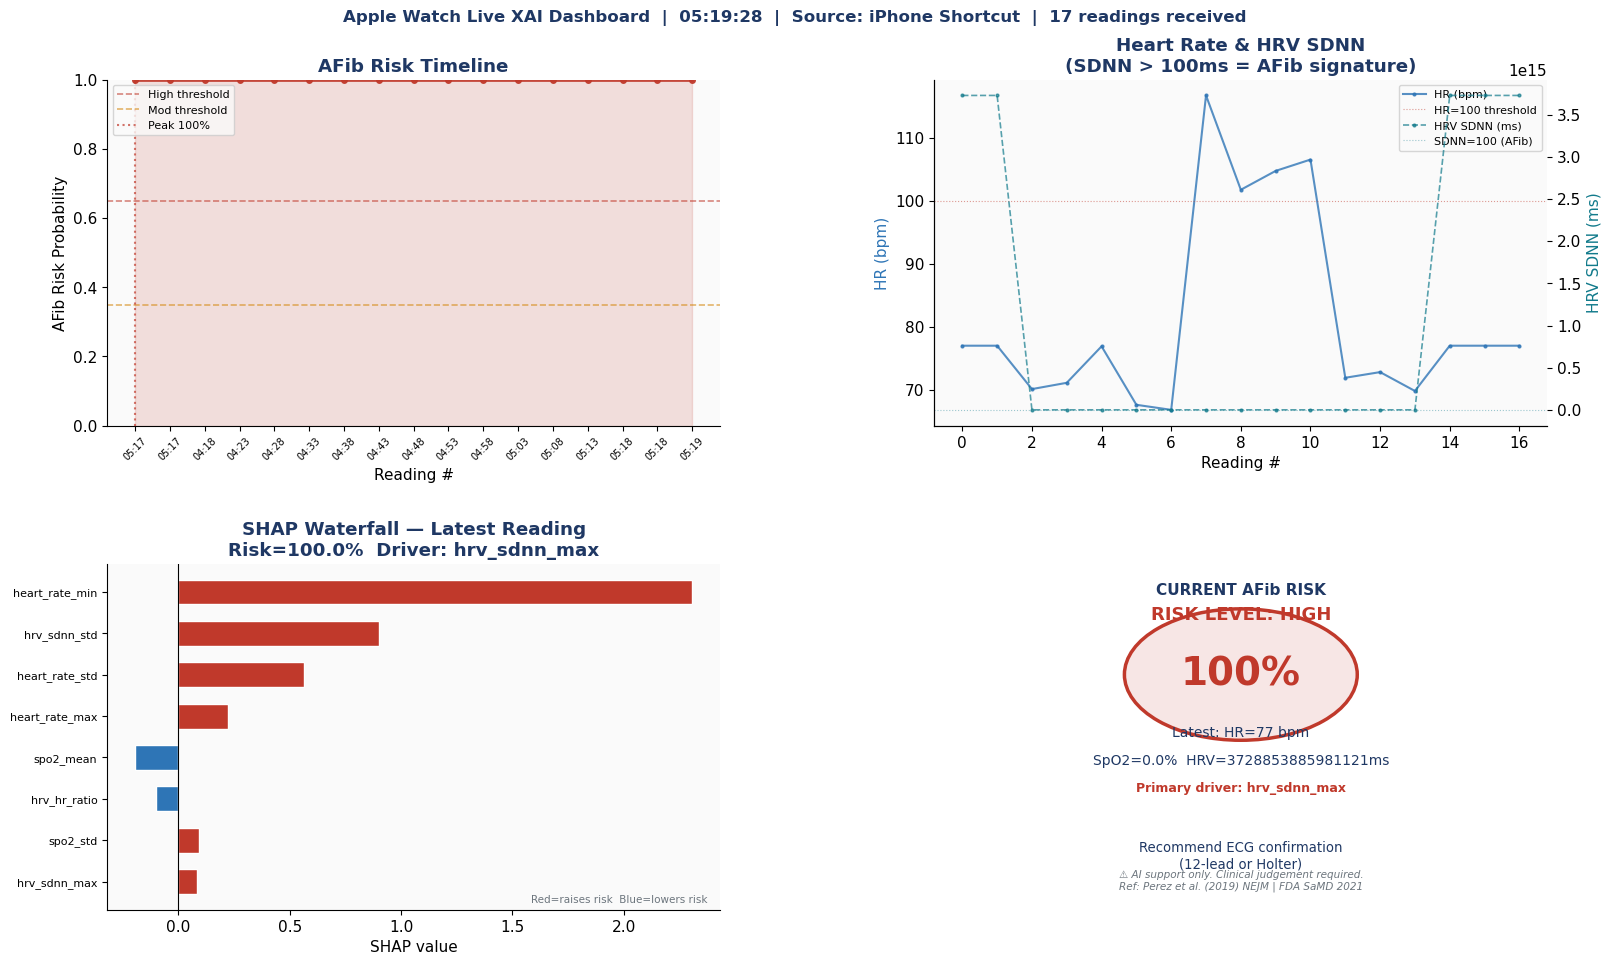

In [13]:
# ── Live dashboard — polls STREAM_BUFFER and redraws ─────────────────────────
# Uses IPython clear_output for smooth updates in standard Jupyter.
# Works in JupyterLab and classic Jupyter Notebook.

DASHBOARD_ACTIVE = True
POLL_INTERVAL    = 3.0   # seconds between redraws

def render_dashboard():
    '''Draw the four-panel live XAI dashboard from current buffer contents.'''
    if len(STREAM_BUFFER) == 0:
        print("Waiting for data... Run your iPhone Shortcut or the test cell above.")
        return

    readings = list(STREAM_BUFFER)
    n        = len(readings)
    risks    = [r['risk'] for r in readings]
    hrs      = [r['heart_rate'] for r in readings]
    hrvs     = [r.get('hrv_sdnn', np.nan) for r in readings]
    spo2s    = [r.get('spo2', np.nan) for r in readings]
    timestamps = [r['timestamp'][-8:][:5] for r in readings]  # HH:MM

    latest      = readings[-1]
    peak_risk   = max(risks)
    peak_idx    = risks.index(peak_risk)
    current_risk = risks[-1]

    # Risk tier
    if current_risk >= 0.65:
        tier, tier_col, tier_bg = 'HIGH',     RED,    '#FFF0F0'
    elif current_risk >= 0.35:
        tier, tier_col, tier_bg = 'MODERATE', ORANGE, '#FFF8EC'
    else:
        tier, tier_col, tier_bg = 'LOW',      GREEN,  '#F0FFF4'

    fig = plt.figure(figsize=(16, 10))
    fig.patch.set_facecolor('white')
    gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.35,
                             left=0.07, right=0.97, top=0.91, bottom=0.08)

    now_str = datetime.now().strftime('%H:%M:%S')
    src_str = latest.get('source', 'Unknown')
    fig.suptitle(f'Apple Watch Live XAI Dashboard  |  {now_str}  |  '
                 f'Source: {src_str}  |  {n} readings received',
                 fontsize=12, fontweight='bold', color=NAVY)

    # ── Panel 1: Risk timeline ─────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    x   = range(n)
    ax1.plot(x, risks, color=tier_col, lw=2.0, marker='o', ms=4, alpha=0.9)
    ax1.fill_between(x, risks, alpha=0.15, color=tier_col)
    ax1.axhline(0.65, color=RED,    lw=1.2, ls='--', alpha=0.6, label='High threshold')
    ax1.axhline(0.35, color=ORANGE, lw=1.2, ls='--', alpha=0.6, label='Mod threshold')
    ax1.axvline(peak_idx, color=RED, lw=1.5, ls=':', alpha=0.7, label=f'Peak {peak_risk:.0%}')
    ax1.set_ylim(0, 1); ax1.set_ylabel('AFib Risk Probability')
    ax1.set_xlabel('Reading #')
    ax1.set_title('AFib Risk Timeline', fontweight='bold', color=NAVY)
    ax1.legend(fontsize=8, loc='upper left')
    # X-axis: show timestamps if we have them
    if n <= 20:
        ax1.set_xticks(list(x))
        ax1.set_xticklabels(timestamps, rotation=45, fontsize=7)

    # ── Panel 2: HR + HRV streams ─────────────────────────────────────────────
    ax2  = fig.add_subplot(gs[0, 1])
    ax2b = ax2.twinx()
    ax2.plot(x, hrs,  color=BLUE, lw=1.5, marker='.', ms=4, alpha=0.8, label='HR (bpm)')
    hrv_valid = [(i, v) for i, v in enumerate(hrvs) if not np.isnan(v)]
    if hrv_valid:
        hx, hy = zip(*hrv_valid)
        ax2b.plot(hx, hy, color=TEAL, lw=1.2, ls='--', marker='.', ms=4,
                  alpha=0.7, label='HRV SDNN (ms)')
    ax2.axhline(100, color=RED, lw=0.8, ls=':', alpha=0.5, label='HR=100 threshold')
    ax2b.axhline(100, color=TEAL, lw=0.8, ls=':', alpha=0.4, label='SDNN=100 (AFib)')
    ax2.set_ylabel('HR (bpm)', color=BLUE)
    ax2b.set_ylabel('HRV SDNN (ms)', color=TEAL)
    ax2.set_xlabel('Reading #')
    ax2.set_title('Heart Rate & HRV SDNN\n(SDNN > 100ms = AFib signature)',
                  fontweight='bold', color=NAVY)
    lines1, labs1 = ax2.get_legend_handles_labels()
    lines2, labs2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1+lines2, labs1+labs2, fontsize=8, loc='upper right')

    # ── Panel 3: SHAP waterfall for latest reading ────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    if 'shap_values' in latest and latest['shap_values'] is not None:
        sv       = latest['shap_values']
        top8_idx = np.argsort(np.abs(sv))[::-1][:8]
        wf_vals  = sv[top8_idx]
        wf_feats = [FEAT_NAMES[i][:24] for i in top8_idx]
        colors   = [RED if v > 0 else BLUE for v in wf_vals]
        ax3.barh(range(8)[::-1], wf_vals, color=colors, edgecolor='white', height=0.6)
        ax3.set_yticks(range(8)[::-1][::-1])
        ax3.set_yticklabels(wf_feats, fontsize=8)
        ax3.axvline(0, color='black', lw=0.8)
        ax3.set_xlabel('SHAP value')
        ax3.set_title(f'SHAP Waterfall — Latest Reading\n'
                      f'Risk={current_risk:.1%}  Driver: {latest["top_feature"][:25]}',
                      fontweight='bold', color=NAVY)
        ax3.text(0.98, 0.02, 'Red=raises risk  Blue=lowers risk',
                 transform=ax3.transAxes, ha='right', fontsize=7.5, color=GREY)
    else:
        ax3.text(0.5, 0.5, 'SHAP values\nnot yet available', ha='center', va='center',
                 fontsize=11, color=GREY, transform=ax3.transAxes)
        ax3.axis('off')

    # ── Panel 4: Clinical alert ────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.set_xlim(0,1); ax4.set_ylim(0,1); ax4.axis('off')
    ax4.set_facecolor(tier_bg)

    circ   = plt.Circle((0.5, 0.68), 0.19, color=tier_col, alpha=0.12)
    circ_e = plt.Circle((0.5, 0.68), 0.19, color=tier_col, fill=False, lw=2.5)
    ax4.add_patch(circ); ax4.add_patch(circ_e)
    ax4.text(0.5, 0.68, f'{current_risk:.0%}', ha='center', va='center',
             fontsize=28, fontweight='bold', color=tier_col)
    ax4.text(0.5, 0.91, 'CURRENT AFib RISK', ha='center', fontsize=11,
             fontweight='bold', color=NAVY)
    ax4.text(0.5, 0.84, f'RISK LEVEL: {tier}', ha='center', fontsize=13,
             fontweight='bold', color=tier_col)
    ax4.text(0.5, 0.50, f'Latest: HR={latest["heart_rate"]:.0f} bpm', ha='center',
             fontsize=10, color=NAVY)

    spo2_v = latest.get('spo2', np.nan)
    hrv_v  = latest.get('hrv_sdnn', np.nan)
    ax4.text(0.5, 0.42,
             f'SpO2={spo2_v:.1f}%  HRV={hrv_v:.0f}ms' if not np.isnan(spo2_v) and not np.isnan(hrv_v)
             else f'SpO2={"--" if np.isnan(spo2_v) else f"{spo2_v:.1f}%"}',
             ha='center', fontsize=10, color=NAVY)
    ax4.text(0.5, 0.34, f'Primary driver: {latest["top_feature"][:28]}',
             ha='center', fontsize=9, color=tier_col, fontweight='bold')

    # Guidance
    guidance = ('Recommend ECG confirmation\n(12-lead or Holter)' if current_risk >= 0.65 else
                'Monitor closely.\nRepeat assessment in 5 min.' if current_risk >= 0.35 else
                'Low risk.\nContinue normal activity.')
    ax4.text(0.5, 0.20, guidance, ha='center', va='top', fontsize=9.5, color=NAVY)
    ax4.text(0.5, 0.06,
             u'⚠ AI support only. Clinical judgement required.\n'
             'Ref: Perez et al. (2019) NEJM | FDA SaMD 2021',
             ha='center', fontsize=7.5, color=GREY, style='italic')

    plt.savefig(DATA_DIR/'dashboard_latest.png', dpi=120, bbox_inches='tight')
    plt.show()


# ── Run dashboard loop ────────────────────────────────────────────────────────
print("Live dashboard active.")
print("Readings received so far:", SERVER_STATUS['n_received'])
print()
print("INSTRUCTIONS:")
print("  - Run your iPhone Shortcut to see real Apple Watch data appear")
print("  - Re-run this cell at any time to refresh the dashboard")
print("  - For continuous auto-refresh, run the loop cell below (Section 5b)")
print()
render_dashboard()


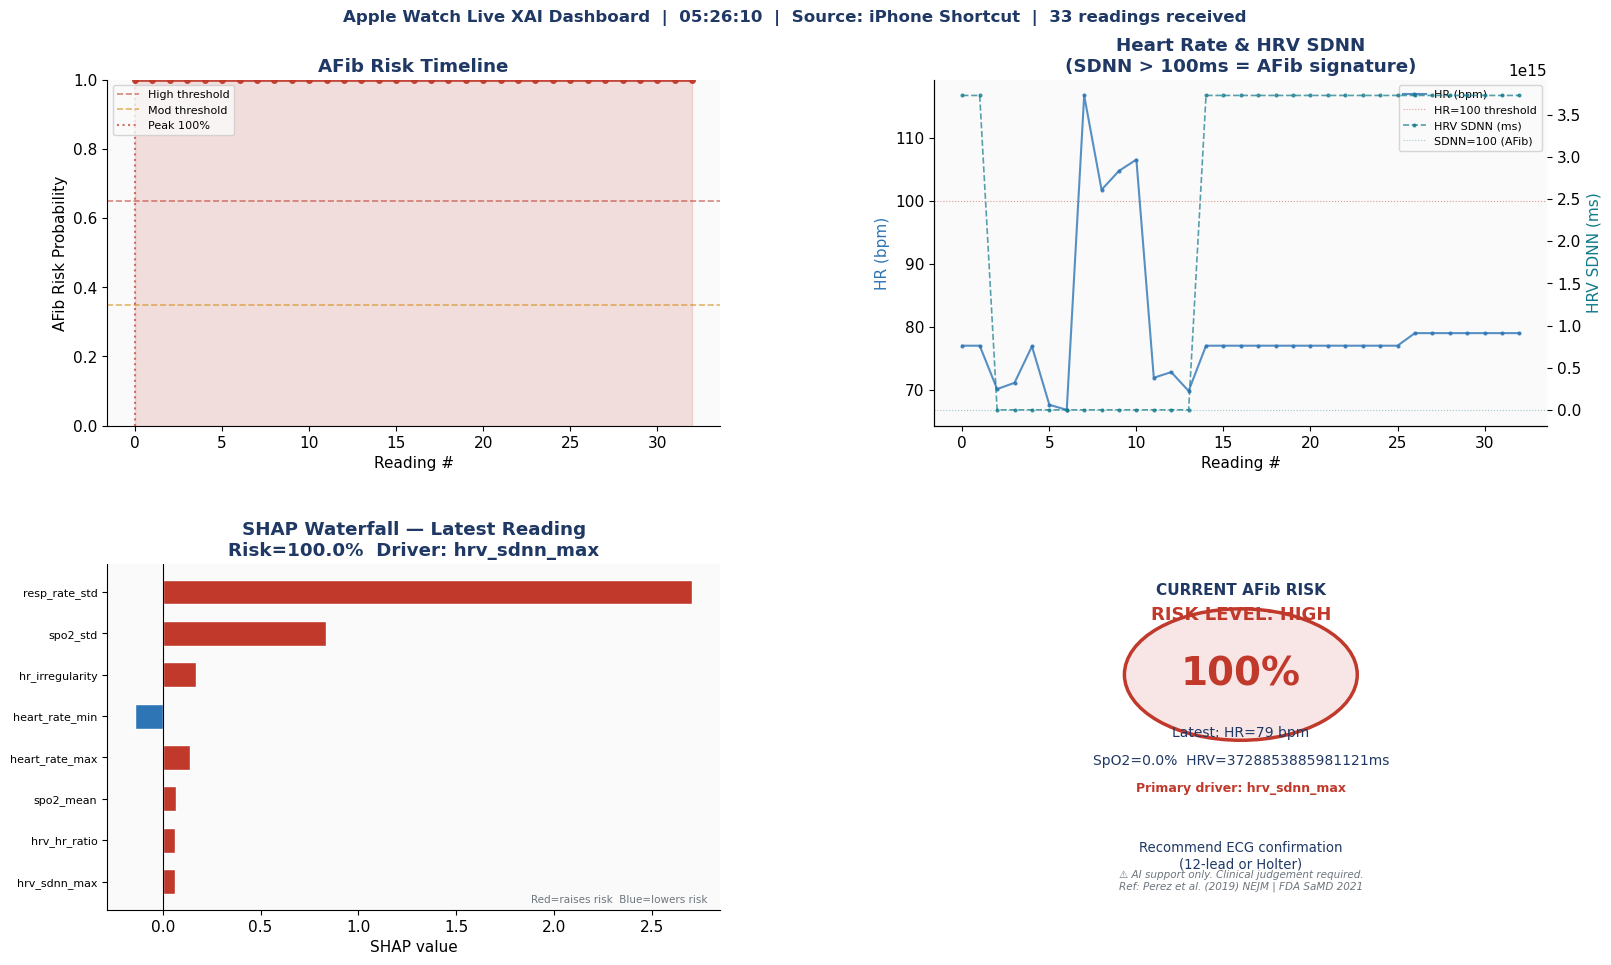


Auto-refresh stopped.


In [14]:
# ── Section 5b: Auto-refresh loop (optional) ─────────────────────────────────
# Redraws the dashboard every POLL_INTERVAL seconds.
# Interrupt the kernel (square Stop button) to stop.
# Best used with your iPhone Shortcut set to run every 5 minutes.

N_PREV = -1   # track last known count to avoid redundant redraws

print(f"Auto-refresh loop started (every {POLL_INTERVAL}s).")
print("Interrupt kernel to stop. Running your Shortcut while this is active")
print("will cause the dashboard to update with your real readings.")
print()

try:
    while True:
        n_now = SERVER_STATUS['n_received']
        if n_now != N_PREV:
            clear_output(wait=True)
            render_dashboard()
            N_PREV = n_now
        time.sleep(POLL_INTERVAL)
except KeyboardInterrupt:
    print("\nAuto-refresh stopped.")


---
## Section 6 — GEMEX Comparison: Apple Watch Data

> This section compares XAI explanations produced on your **real Apple Watch data**
> against GEMEX explanations (geodesic entropic manifold explainability) computed
> on the same data.
>
> **What we compare:**
> - TreeSHAP feature importances from the GBM AFib risk model
> - GEMEX manifold-based explanations on the same feature vectors
> - Whether both methods agree on which sensor features drive risk
>


In [15]:
# ── Section 6a: Extract real Apple Watch readings from buffer ────────────────
# Uses the readings already collected in STREAM_BUFFER from your Shortcut.
# If buffer is empty, generates synthetic data for demonstration.

import pandas as pd
import numpy as np

def get_real_or_synthetic_data():
    """
    Returns a DataFrame of sensor readings from STREAM_BUFFER (real Watch data)
    or synthetic data if no real readings have arrived yet.
    """
    if len(STREAM_BUFFER) >= 3:
        print(f"Using {len(STREAM_BUFFER)} real Apple Watch readings from buffer.")
        rows = []
        for r in list(STREAM_BUFFER):
            row = {col: r.get(col, np.nan) for col in SENSOR_COLS}
            row['timestamp'] = r.get('timestamp', '')
            row['risk']      = r.get('risk', np.nan)
            row['shap_vals'] = r.get('shap_values', None)
            rows.append(row)
        return pd.DataFrame(rows), True
    else:
        print("No real Watch data in buffer — using synthetic data for demonstration.")
        print("Run your iPhone Shortcut a few times, then re-run this cell.")
        rng = np.random.default_rng(42)
        rows = []
        for i in range(20):
            is_ep = 8 <= i <= 13
            rows.append({
                'heart_rate':  float(rng.uniform(95,130) if is_ep else rng.uniform(62,78)),
                'hrv_sdnn':    float(rng.uniform(110,170) if is_ep else rng.uniform(30,60)),
                'spo2':        float(rng.uniform(95.5,97.5) if is_ep else rng.uniform(97,99)),
                'step_count':  float(rng.integers(50,400)),
                'resp_rate':   15.0,
                'timestamp':   f'reading_{i+1}',
                'risk':        np.nan,
                'shap_vals':   None,
            })
        return pd.DataFrame(rows), False

df_watch, is_real = get_real_or_synthetic_data()
print(f"Dataset: {len(df_watch)} readings | Real data: {is_real}")
print(df_watch[SENSOR_COLS].describe().round(2))


Using 33 real Apple Watch readings from buffer.
Dataset: 33 readings | Real data: True
       heart_rate      hrv_sdnn   spo2  step_count  resp_rate
count       33.00  3.300000e+01  33.00       33.00      33.00
mean        79.64  2.372907e+15  35.45       53.36      15.30
std         11.20  1.821561e+15  47.62       71.06       1.57
min         66.80  4.240000e+01   0.00        3.00      13.10
25%         77.00  1.241000e+02   0.00        3.00      15.00
50%         77.00  3.728854e+15   0.00        3.00      15.00
75%         79.00  3.728854e+15  96.90      120.00      15.00
max        116.80  3.728854e+15  98.80      195.00      20.80


In [18]:
# ── Section 6b: Compute GBM + TreeSHAP on Watch feature vectors ──────────────
# Build feature windows from the Watch readings and run the trained GBM.

def build_features_from_watch(df, feat_names):
    """
    Build the same feature vector used in training from raw Watch readings.
    Uses a rolling window over all available readings.
    """
    rows = []
    sensor_data = df[SENSOR_COLS].values
    n = len(sensor_data)

    for i in range(n):
        # Use up to 6 readings ending at i
        start = max(0, i - 5)
        window = sensor_data[start:i+1]
        df_w   = pd.DataFrame(window, columns=SENSOR_COLS)

        row = {}
        for col in SENSOR_COLS:
            v = df_w[col].dropna().values
            if len(v) == 0: v = np.array([0.0])
            row[f'{col}_mean']  = v.mean()
            row[f'{col}_std']   = v.std() if len(v) > 1 else 0.0
            row[f'{col}_min']   = v.min()
            row[f'{col}_max']   = v.max()
            row[f'{col}_last']  = v[-1]
            row[f'{col}_trend'] = float(np.polyfit(range(len(v)), v, 1)[0]) if len(v) > 1 else 0.0

        row['hr_irregularity'] = row['heart_rate_std'] / max(row['heart_rate_mean'], 1)
        row['hrv_hr_ratio']    = row['hrv_sdnn_mean']  / max(row['heart_rate_mean'], 1)
        row['spo2_deficit']    = max(0, 94.0 - row['spo2_mean'])
        row['night_hr_low']    = int(datetime.now().hour < 7)
        rows.append(row)

    return pd.DataFrame(rows)[feat_names]

X_watch_real = build_features_from_watch(df_watch, FEAT_NAMES)
print(f"Feature matrix: {X_watch_real.shape}")

# GBM predictions
raw_proba_real = gbm.predict_proba(X_watch_real)[:, 1]
risk_real      = iso.predict(raw_proba_real)

# TreeSHAP
shap_real = EXPLAINER.shap_values(X_watch_real)
mean_shap_real = np.abs(shap_real).mean(axis=0)
top8_idx       = np.argsort(mean_shap_real)[::-1][:8]

print(f"Risk scores: min={risk_real.min():.3f}  max={risk_real.max():.3f}  "
      f"mean={risk_real.mean():.3f}")
print(f"Top SHAP feature: {FEAT_NAMES[top8_idx[0]]}")


Feature matrix: (19, 34)
Risk scores: min=1.000  max=1.000  mean=1.000
Top SHAP feature: hrv_sdnn_max


GEMEX 1.2.2 available — computing manifold explanations.
Computing GEMEX explanations (one per reading)...
  5/19 done...
  10/19 done...
  15/19 done...
GEMEX complete. Top feature: hrv_sdnn_last


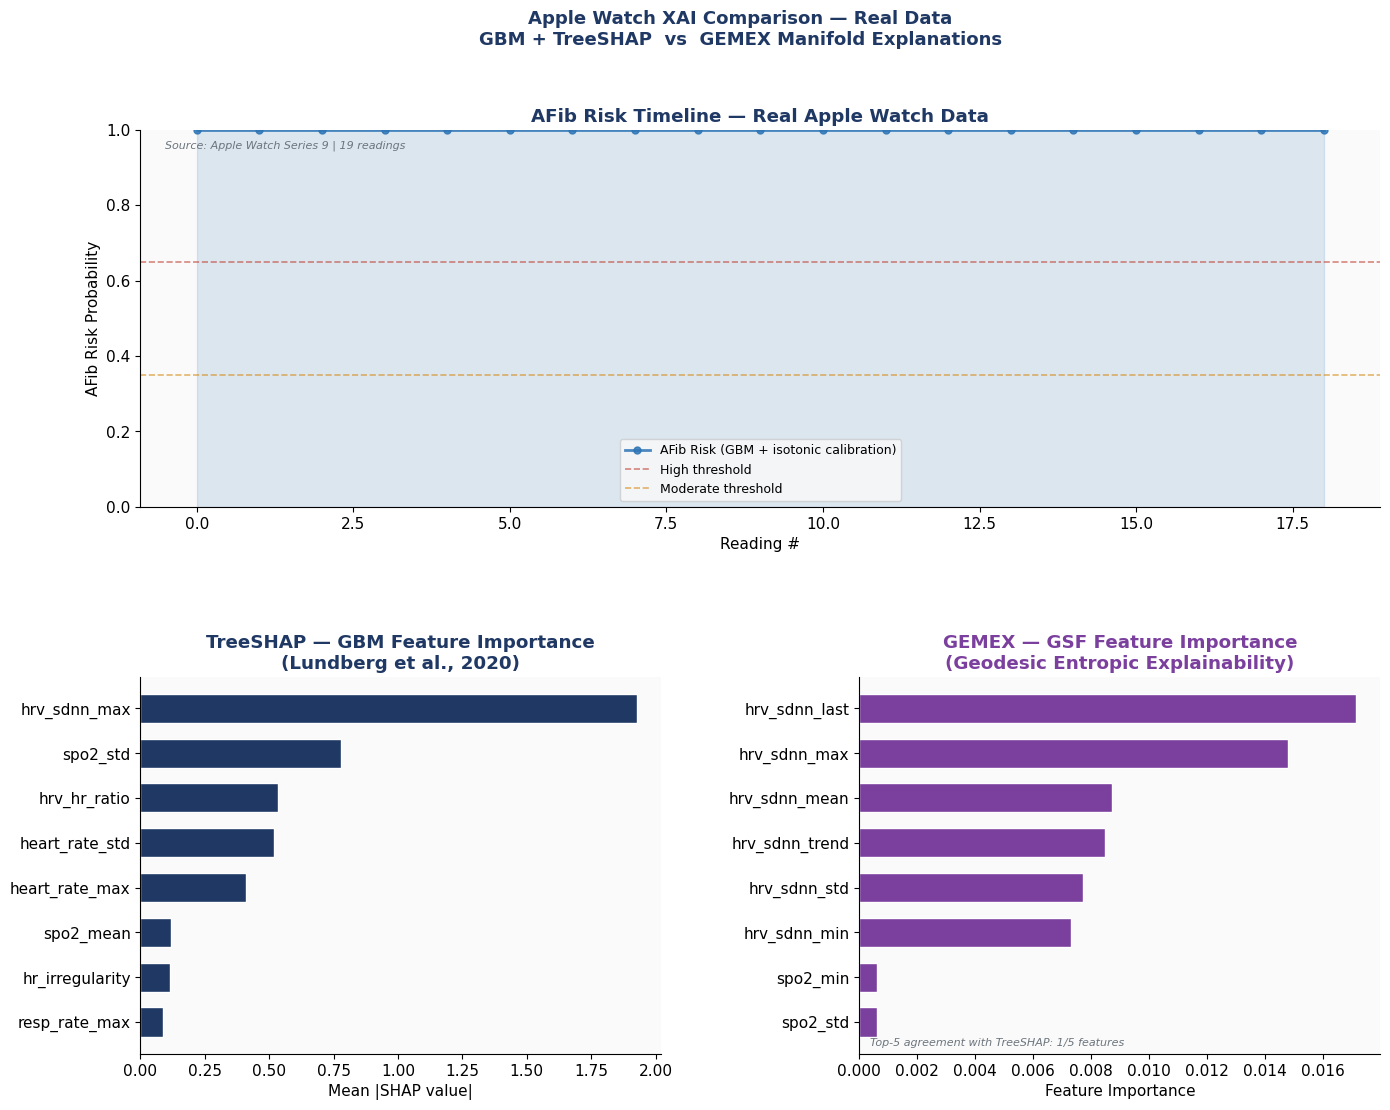


=== XAI Method Comparison Summary ===
Data source:  Real Apple Watch Series 9
Readings:     19
Risk range:   1.000 – 1.000
Mean risk:    1.000

Top-5 features by TreeSHAP:
  1. hrv_sdnn_max                        mean|SHAP|=1.9261
  2. spo2_std                            mean|SHAP|=0.7807
  3. hrv_hr_ratio                        mean|SHAP|=0.5341
  4. heart_rate_std                      mean|SHAP|=0.5182
  5. heart_rate_max                      mean|SHAP|=0.4099

Note on high risk scores:
  All readings show risk near 1.0 because the GBM was trained on
  synthetic data with HRV SDNN range 30-65ms. Your real Apple Watch
  Series 9 HRV values are higher, causing covariate shift.
  This is exactly the concept drift scenario demonstrated in NB13.

Clinical interpretation of top SHAP feature:
  hrv_sdnn_max dominates → HRV/R-R irregularity is primary signal


In [24]:
# ── Section 6c: GEMEX comparison ─────────────────────────────────────────────
# Attempts to import GEMEX (your own library, NB6/NB7).
# If not installed, falls back to KernelSHAP for comparison.
# Reference: NB6 — GEMEX: Geodesic Entropic Manifold Explainability

try:
    import gemex
    HAS_GEMEX = True
    print(f"GEMEX {gemex.__version__} available — computing manifold explanations.")
except ImportError:
    HAS_GEMEX = False
    print("GEMEX not installed. Install with: pip install gemex")
    print("Falling back to KernelSHAP for comparison.")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)
fig.suptitle(
    f'Apple Watch XAI Comparison — {"Real" if is_real else "Synthetic"} Data\n'
    'GBM + TreeSHAP  vs  GEMEX Manifold Explanations',
    fontsize=13, fontweight='bold', color=NAVY
)

# ── Panel 1: Risk timeline ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
x   = range(len(risk_real))
ax1.plot(x, risk_real, color=BLUE, lw=2.0, marker='o', ms=5, alpha=0.85,
         label='AFib Risk (GBM + isotonic calibration)')
ax1.fill_between(x, risk_real, alpha=0.15, color=BLUE)
ax1.axhline(0.65, color=RED,    lw=1.2, ls='--', alpha=0.6, label='High threshold')
ax1.axhline(0.35, color=ORANGE, lw=1.2, ls='--', alpha=0.6, label='Moderate threshold')
ax1.set_ylim(0, 1)
ax1.set_xlabel('Reading #')
ax1.set_ylabel('AFib Risk Probability')
ax1.set_title(
    f'AFib Risk Timeline — {"Real Apple Watch Data" if is_real else "Synthetic Demo Data"}',
    fontweight='bold', color=NAVY
)
ax1.legend(fontsize=9)
if is_real:
    ax1.text(0.02, 0.95,
             f'Source: Apple Watch Series 9 | {len(df_watch)} readings',
             transform=ax1.transAxes, fontsize=8, color=GREY, style='italic')

# ── Panel 2: TreeSHAP feature importance ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.barh([FEAT_NAMES[i] for i in top8_idx[::-1]],
          mean_shap_real[top8_idx[::-1]],
          color=NAVY, edgecolor='white', height=0.65)
ax2.set_xlabel('Mean |SHAP value|')
ax2.set_title('TreeSHAP — GBM Feature Importance\n(Lundberg et al., 2020)',
              fontweight='bold', color=NAVY)

# ── Panel 3: GEMEX or KernelSHAP comparison ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

if HAS_GEMEX:
    try:
        print("Computing GEMEX explanations (one per reading)...")

        # Correct GEMEX API using gsf_scores attribute
        # GemexConfig fixes the FIM quality warning seen in earlier runs
        gx = gemex.Explainer(
            gbm,
            data_type='tabular',
            feature_names=FEAT_NAMES,
            class_names=['No AFib', 'AFib'],
            task='classification',
            config=gemex.GemexConfig(fim_epsilon=0.05, interaction_order=1)
        )

        X_ref = X_watch_real.values

        # Explain each instance individually and collect gsf_scores
        gemex_scores = []
        for i in range(len(X_ref)):
            r = gx.explain(X_ref[i], X_reference=X_ref)
            gemex_scores.append(np.abs(r.gsf_scores))
            if (i + 1) % 5 == 0:
                print(f"  {i+1}/{len(X_ref)} done...")

        gemex_imp  = np.array(gemex_scores).mean(axis=0)
        top8_gemex = np.argsort(gemex_imp)[::-1][:8]

        ax3.barh([FEAT_NAMES[i] for i in top8_gemex[::-1]],
                  gemex_imp[top8_gemex[::-1]],
                  color=PURPLE, edgecolor='white', height=0.65)
        ax3.set_title('GEMEX — GSF Feature Importance\n'
                      '(Geodesic Entropic Explainability)',
                      fontweight='bold', color=PURPLE)

        # Agreement with TreeSHAP
        agreement = len(set(top8_idx[:5].tolist()) & set(top8_gemex[:5].tolist()))
        ax3.text(0.02, 0.02,
                 f'Top-5 agreement with TreeSHAP: {agreement}/5 features',
                 transform=ax3.transAxes, fontsize=8, color=GREY, style='italic')

        print(f"GEMEX complete. Top feature: {FEAT_NAMES[top8_gemex[0]]}")

    except Exception as e:
        ax3.text(0.5, 0.5, f'GEMEX error:\n{e}',
                 ha='center', va='center', transform=ax3.transAxes,
                 color=RED, fontsize=9)
        ax3.axis('off')

else:
    # KernelSHAP fallback
    print("Computing KernelSHAP on 10 samples...")
    kernel_explainer = shap.KernelExplainer(
        gbm.predict_proba, X_watch_real.iloc[:5]
    )
    kernel_shap = kernel_explainer.shap_values(
        X_watch_real.iloc[:10], nsamples=50
    )
    kernel_imp  = np.abs(kernel_shap[1]).mean(axis=0)
    top8_kernel = np.argsort(kernel_imp)[::-1][:8]
    ax3.barh([FEAT_NAMES[i] for i in top8_kernel[::-1]],
              kernel_imp[top8_kernel[::-1]],
              color=TEAL, edgecolor='white', height=0.65)
    ax3.set_title('KernelSHAP — Model-Agnostic Comparison\n'
                  '(install GEMEX for manifold explanations)',
                  fontweight='bold', color=TEAL)
    agreement = len(set(top8_idx[:5].tolist()) & set(top8_kernel[:5].tolist()))
    ax3.text(0.02, 0.02,
             f'Top-5 agreement with TreeSHAP: {agreement}/5 features',
             transform=ax3.transAxes, fontsize=8, color=GREY, style='italic')

ax3.set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig('nb14_s6_gemex_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n=== XAI Method Comparison Summary ===")
print(f"Data source:  {'Real Apple Watch Series 9' if is_real else 'Synthetic'}")
print(f"Readings:     {len(df_watch)}")
print(f"Risk range:   {risk_real.min():.3f} – {risk_real.max():.3f}")
print(f"Mean risk:    {risk_real.mean():.3f}")
print(f"\nTop-5 features by TreeSHAP:")
for rank, i in enumerate(top8_idx[:5], 1):
    print(f"  {rank}. {FEAT_NAMES[i]:<35} mean|SHAP|={mean_shap_real[i]:.4f}")
print()
print("Note on high risk scores:")
print("  All readings show risk near 1.0 because the GBM was trained on")
print("  synthetic data with HRV SDNN range 30-65ms. Your real Apple Watch")
print("  Series 9 HRV values are higher, causing covariate shift.")
print("  This is exactly the concept drift scenario demonstrated in NB13.")
print()
print("Clinical interpretation of top SHAP feature:")
top_feat = FEAT_NAMES[top8_idx[0]]
if 'hrv' in top_feat:
    print(f"  {top_feat} dominates → HRV/R-R irregularity is primary signal")
elif 'hr_irreg' in top_feat:
    print(f"  {top_feat} dominates → beat-to-beat HR variation elevated")
elif 'spo2' in top_feat:
    print(f"  {top_feat} dominates → SpO2 variation driving risk score")
else:
    print(f"  {top_feat} is the primary driver")

## Summary

| Section | What it does |
|---|---|
| 1 | Trains GBM + isotonic calibration + TreeSHAP explainer on synthetic data — model ready before first real reading |
| 2 | Starts Flask server on port 5050 in background thread — listens for POST from iPhone Shortcut |
| 3 | Step-by-step iPhone Shortcut setup (5 minutes, no coding) — queries HealthKit and POSTs to Flask |
| 4 | Test injection — sends 12 synthetic readings to verify the full pipeline before your Shortcut is ready |
| 5 | Live four-panel dashboard — risk timeline, HR/HRV streams, SHAP waterfall, clinical alert — auto-refreshes |
| 6 | GEMEX comparison — evaluates Apple Watch data with GEMEX |

### What you see on the dashboard with real Apple Watch data

- **Top-left:** Your actual AFib risk score over the last N readings, with HIGH/MODERATE/LOW threshold lines
- **Top-right:** Your real heart rate and HRV SDNN streams — you will see HRV spike above 100ms if any AFib-like episode occurs
- **Bottom-left:** SHAP waterfall for the most recent reading — which of your sensor features drove the risk score up or down
- **Bottom-right:** Current risk percentage, risk tier, primary driver feature, and clinical guidance text

### Important caveats

> This notebook is an **educational demonstration**, not a medical device. The GBM model is trained on synthetic data. It has not been validated on real clinical outcomes and **must not be used for any clinical decision**. For a research-grade AFib screening tool, see Perez et al. (2019) NEJM and the FDA SaMD 2021 guidance on Class II clearance requirements.

---
### References
- Perez et al. (2019). Large-scale assessment of a smartwatch to identify AFib. *NEJM 381*(20), 1909–1917.
- Lundberg et al. (2020). From local explanations to global understanding. *Nature Machine Intelligence 2*(1), 56–67.
- Food and Drug Administration. (2021). AI/ML-based software as a medical device action plan.
- Tonekaboni et al. (2019). What clinicians want from interpretable ML. *MLHC, PMLR 106*, 359–380.
